<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Xecption_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           6212        153                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13254        303                1  
mubashirsidiki/student-academic-performance-500-students           Student Academic Performance - 500 Students               6413  2026-04-07 14:23:47.547000           1334         37     

In [3]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:20<00:00, 40.4MB/s]



In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

DATA_DIR = "/content/PetImages"   # change if needed
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

from PIL import Image
import os

# Identify and remove corrupt images
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(DATA_DIR, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images due to invalid JFIF header")

Deleted 1590 images due to invalid JFIF header


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


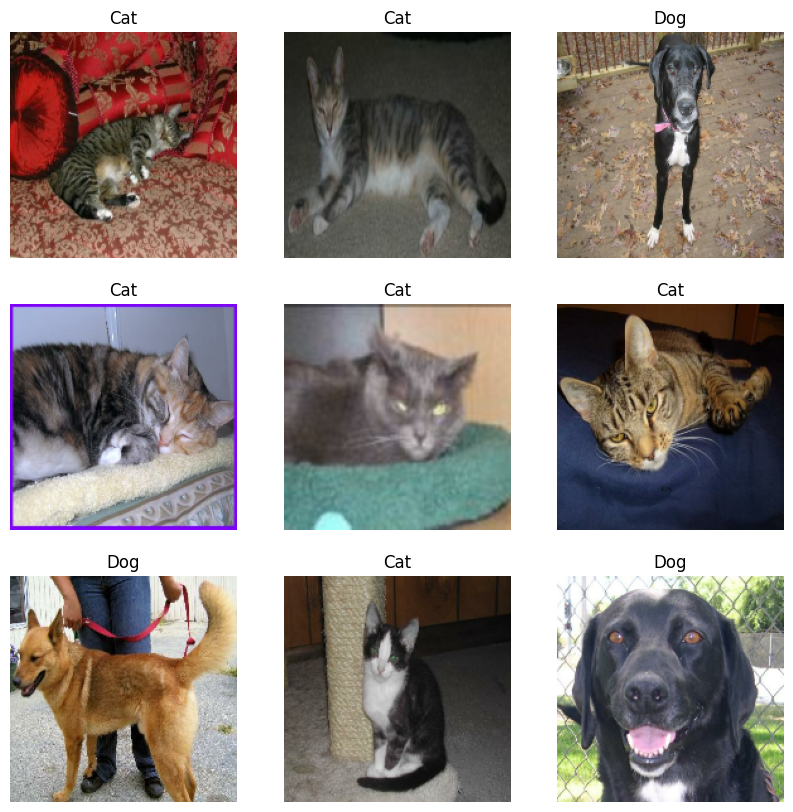

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

class_names = train_ds.class_names

for images, labels in train_ds.take(12):
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)

for size in [32,64,128,256,512]:
  residual = x
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.SeparableConv2D(size, 3, padding='same', use_bias=False)(x)

  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.SeparableConv2D(size, 3, padding='same', use_bias=False)(x)

  x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

  residual = layers.Conv2D(
      size, 1, strides=2, padding='same', use_bias=False)(residual)
  x = layers.add([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 180, 180,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 180, 180,  │          0 │ sequential_2[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 176, 176,  │      2,400 │ rescaling_2[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_18 │ (None, 176, 176,  │      1,312 │ activation_18[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_19 │ (None, 176, 176,  │      1,312 │ activation_19[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 88, 88,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 88, 88,    │      1,024 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 88, 88,    │          0 │ max_pooling2d_9[… │
│                     │ 32)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        128 │ add_9[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 88, 88,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_20 │ (None, 88, 88,    │      2,336 │ activation_20[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        256 │ separable_conv2d

 Total params: 721,857 (2.75 MB)

 Trainable params: 718,849 (2.74 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [19]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="Xecption_model_classification.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [20]:
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 116s 187ms/step - accuracy: 0.6366 - loss: 0.6374 - val_accuracy: 0.5120 - val_loss: 0.8574
Epoch 2/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - accuracy: 0.7427 - loss: 0.5243 - val_accuracy: 0.5775 - val_loss: 0.7435
Epoch 3/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - accuracy: 0.8060 - loss: 0.4248 - val_accuracy: 0.8360 - val_loss: 0.3744
Epoch 4/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 113s 192ms/step - accuracy: 0.8424 - loss: 0.3585 - val_accuracy: 0.7050 - val_loss: 0.6165
Epoch 5/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - accuracy: 0.8682 - loss: 0.3117 - val_accuracy: 0.8469 - val_loss: 0.3324
Epoch 6/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 108s 184ms/step - accuracy: 0.8838 - loss: 0.2717 - val_accuracy: 0.7900 - val_loss: 0.4504
Epoch 7/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 109s 186ms/step - accuracy: 0.8977 - loss: 0.2487 - val_accuracy: 0.8727 - val_loss: 0.3078
Epoch 8/15
586/586 ━━━━━━━━━━━━━━━━━━━━ 108s 185ms/step - accuracy: 0.9039 -

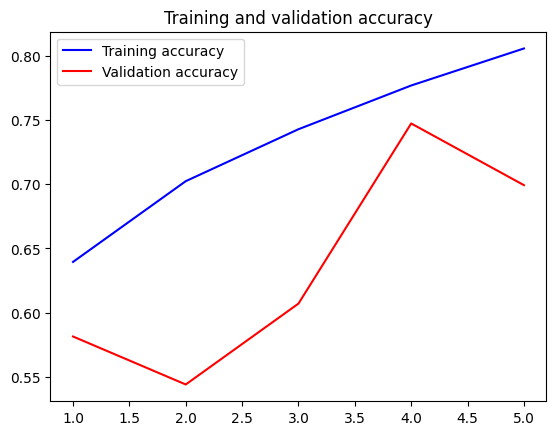

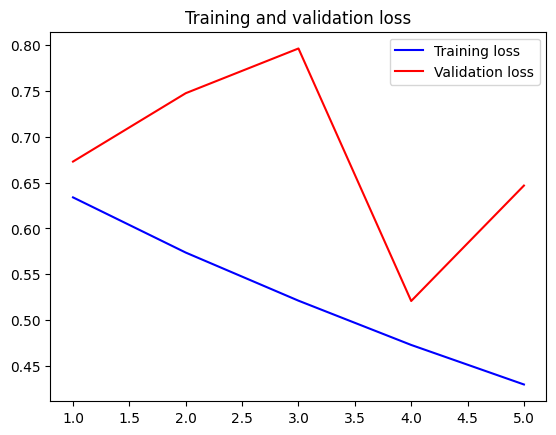

In [17]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()